In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [2]:
df = pd.read_csv("CICIDS_multiclass_processed.csv")

In [3]:
df.head()

,Bwd Packet Length Max,Flow Duration,Flow IAT Std,Flow IAT Mean,Bwd Packet Length Min,Bwd IAT Max,PSH Flag Count,Bwd IAT Std,FIN Flag Count,Min Packet Length,Flow IAT Min,ACK Flag Count,label_multi_enc
0,0.000000,0.000118,0.000092,0.000040,0.000000,0.000118,0.0,0.000000,1.0,0.000000,2.416666e-07,0.0,4
1,0.015207,0.000674,0.000238,0.000112,0.000000,0.000335,1.0,0.000271,0.0,0.000000,1.500000e-07,0.0,0
2,0.005581,0.002208,0.001027,0.000315,0.037638,0.001948,0.0,0.001598,0.0,0.030387,1.333333e-07,0.0,0
3,0.000000,0.000150,0.000150,0.000075,0.000000,0.000000,0.0,0.000000,1.0,0.004144,1.250000e-07,0.0,4
4,0.006349,0.000541,0.000000,0.000541,0.042818,0.000000,0.0,0.000000,0.0,0.036602,5.409083e-04,0.0,0


In [4]:
df.isnull().sum()

Bwd Packet Length Max    0
Flow Duration            0
Flow IAT Std             0
Flow IAT Mean            0
Bwd Packet Length Min    0
Bwd IAT Max              0
PSH Flag Count           0
Bwd IAT Std              0
FIN Flag Count           0
Min Packet Length        0
Flow IAT Min             0
ACK Flag Count           0
label_multi_enc          0
dtype: int64

In [5]:
print("Shape of dataset:", df.shape)

Shape of dataset: (2522362, 13)


In [6]:
df.columns

Index(['Bwd Packet Length Max', 'Flow Duration', 'Flow IAT Std',
       'Flow IAT Mean', 'Bwd Packet Length Min', 'Bwd IAT Max',
       'PSH Flag Count', 'Bwd IAT Std', 'FIN Flag Count', 'Min Packet Length',
       'Flow IAT Min', 'ACK Flag Count', 'label_multi_enc'],
      dtype='object')

In [7]:
print("\nClass distribution:")
print(df['label_multi_enc'].value_counts().sort_index())


Class distribution:
label_multi_enc
0     2096484
1        1953
2      128016
3       10286
4      172849
5        5228
6        5385
7        5933
8          11
9          36
10      90819
11       3219
12       1470
13         21
14        652
Name: count, dtype: int64


In [8]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop(columns=['label_multi_enc'])
y = df['label_multi_enc']

# Stratified split (preserves class proportions)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# Distribution check
print("\nTraining class distribution:")
print(y_train.value_counts().sort_index())

print("\nTesting class distribution:")
print(y_test.value_counts().sort_index())


Train shape: (2017889, 12)
Test shape: (504473, 12)

Training class distribution:
label_multi_enc
0     1677187
1        1562
2      102413
3        8229
4      138279
5        4182
6        4308
7        4746
8           9
9          29
10      72655
11       2575
12       1176
13         17
14        522
Name: count, dtype: int64

Testing class distribution:
label_multi_enc
0     419297
1        391
2      25603
3       2057
4      34570
5       1046
6       1077
7       1187
8          2
9          7
10     18164
11       644
12       294
13         4
14       130
Name: count, dtype: int64


Because you have classes with very few samples (like class 8 = 9 samples, class 13 = 17 samples), normal SMOTE may fail (since it needs at least k_neighbors+1 samples).

If a class is too small for SMOTE, we fall back to RandomOverSampler.

Majority = class 0 (1.67M)

Medium classes = 2, 4, 10 (tens of thousands)

Minority = 8 (9 samples), 13 (17), 9 (29) → too tiny for SMOTE safely

In [9]:
from collections import Counter
import pandas as pd
from imblearn.over_sampling import SMOTE, RandomOverSampler

print("Before resampling:", Counter(y_train))

# find smallest class count
min_count = min(Counter(y_train).values())

# safe k_neighbors for SMOTE
k = min(5, max(1, min_count - 1))  

if min_count <= 5:  
    # too few samples for SMOTE → use random oversampling
    ros = RandomOverSampler(random_state=42)
    X_train_res, y_train_res = ros.fit_resample(X_train, y_train)
    print("Used RandomOverSampler (too few samples for SMOTE).")
else:
    sm = SMOTE(k_neighbors=k, random_state=42)
    X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
    print(f"Used SMOTE with k_neighbors={k}.")

print("After resampling:", Counter(y_train_res))
print("Resampled train shape:", X_train_res.shape)


Before resampling: Counter({0: 1677187, 4: 138279, 2: 102413, 10: 72655, 3: 8229, 7: 4746, 6: 4308, 5: 4182, 11: 2575, 1: 1562, 12: 1176, 14: 522, 9: 29, 13: 17, 8: 9})
Used SMOTE with k_neighbors=5.
After resampling: Counter({4: 1677187, 0: 1677187, 10: 1677187, 2: 1677187, 12: 1677187, 3: 1677187, 7: 1677187, 1: 1677187, 5: 1677187, 14: 1677187, 6: 1677187, 11: 1677187, 8: 1677187, 9: 1677187, 13: 1677187})
Resampled train shape: (25157805, 12)


##### DECISION TREE

Decision Tree Performance:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98    419297
           1       0.04      0.88      0.07       391
           2       0.99      1.00      0.99     25603
           3       0.88      0.98      0.93      2057
           4       0.98      0.98      0.98     34570
           5       0.76      0.96      0.85      1046
           6       0.80      0.92      0.86      1077
           7       0.74      0.85      0.79      1187
           8       1.00      1.00      1.00         2
           9       0.31      0.57      0.40         7
          10       0.99      1.00      0.99     18164
          11       0.62      0.93      0.74       644
          12       0.09      0.57      0.15       294
          13       0.01      0.25      0.01         4
          14       0.27      0.39      0.32       130

    accuracy                           0.97    504473
   macro avg       0.63      0.82      0.67    504473

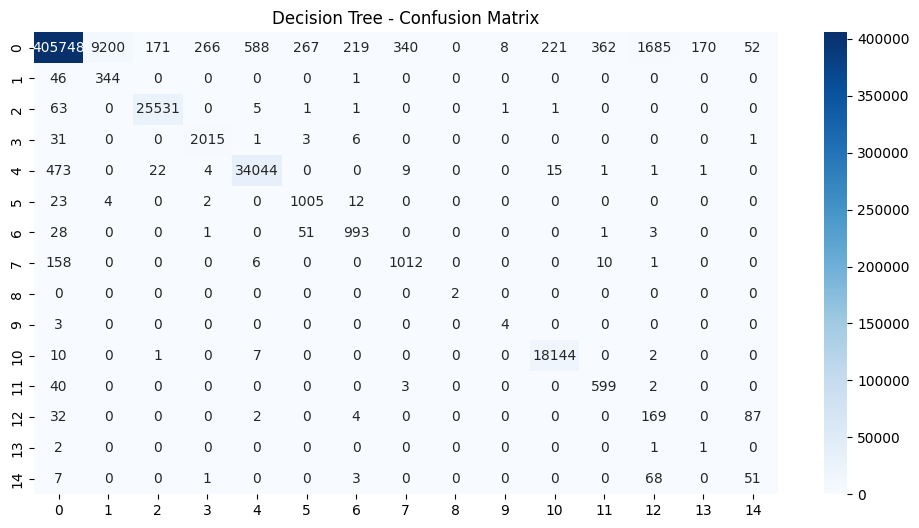

In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Train Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_res, y_train_res)

# Predictions on test set (NOT resampled, real distribution)
y_pred_dt = dt.predict(X_test)

# Classification report
print("Decision Tree Performance:")
print(classification_report(y_test, y_pred_dt))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(12,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Decision Tree - Confusion Matrix")
plt.show()


##### RANDOM FOREST

Random Forest Performance:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98    419297
           1       0.04      0.91      0.07       391
           2       0.99      1.00      1.00     25603
           3       0.88      0.98      0.93      2057
           4       0.98      0.99      0.98     34570
           5       0.78      0.98      0.87      1046
           6       0.83      0.95      0.88      1077
           7       0.73      0.90      0.81      1187
           8       1.00      1.00      1.00         2
           9       0.80      0.57      0.67         7
          10       0.99      1.00      0.99     18164
          11       0.62      0.93      0.75       644
          12       0.09      0.54      0.15       294
          13       0.01      0.25      0.01         4
          14       0.30      0.39      0.34       130

    accuracy                           0.97    504473
   macro avg       0.67      0.82      0.70    504473

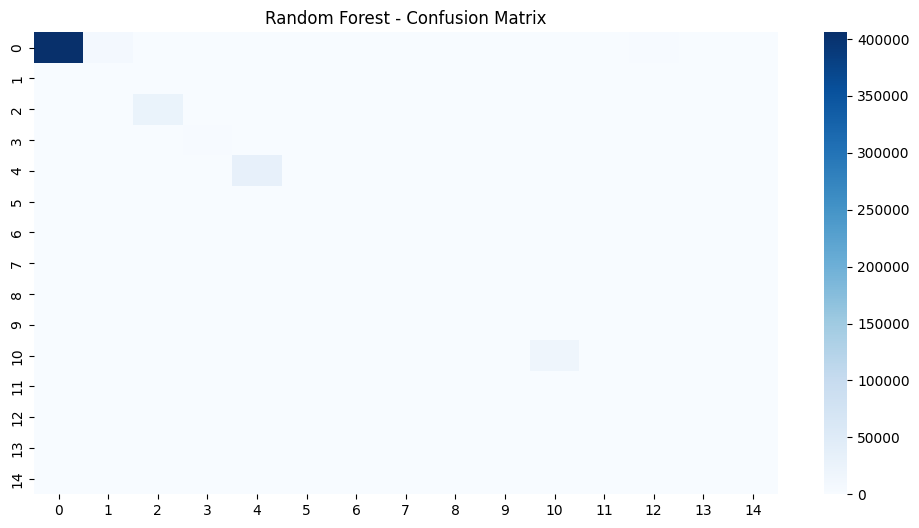

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Train Random Forest on SMOTE-balanced training set
rf = RandomForestClassifier(
    n_estimators=200,       # number of trees
    max_depth=None,         # let trees grow fully
    class_weight=None,      # not needed since we used SMOTE
    random_state=42,
    n_jobs=-1               # use all CPU cores
)
rf.fit(X_train_res, y_train_res)

# Predictions on real-world test set
y_pred_rf = rf.predict(X_test)

# Classification report
print("Random Forest Performance:")
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf) 
plt.figure(figsize=(12,6))
sns.heatmap(cm, annot=False, fmt="d", cmap="Blues")
plt.title("Random Forest - Confusion Matrix")
plt.show()


Class 1 (very rare) → recall stayed very high (0.91), but precision is still low → model finds positives, but too many false alarms.

Classes 5, 6, 7, 11, 12, 13, 14 → recall improved compared to Decision Tree.

Macro-average F1 (0.70) is better than DT’s 0.67 → showing that RF generalizes better.

Overall, RF is much more stable than a single Decision Tree (expected).

In [12]:
pip install xgboost

   ---------------------------------------- 0.0/56.8 MB ? eta -:--:--
   ---------------------------------------- 0.3/56.8 MB ? eta -:--:--
   ---------------------------------------- 0.5/56.8 MB 985.5 kB/s eta 0:00:58
   - -------------------------------------- 1.6/56.8 MB 2.7 MB/s eta 0:00:21
   - -------------------------------------- 1.8/56.8 MB 2.2 MB/s eta 0:00:26
   - -------------------------------------- 2.6/56.8 MB 2.5 MB/s eta 0:00:22
   -- ------------------------------------- 3.1/56.8 MB 2.5 MB/s eta 0:00:22
   -- ------------------------------------- 3.4/56.8 MB 2.5 MB/s eta 0:00:22
   -- ------------------------------------- 3.9/56.8 MB 2.4 MB/s eta 0:00:23
   --- ------------------------------------ 4.5/56.8 MB 2.5 MB/s eta 0:00:21
   --- ------------------------------------ 4.7/56.8 MB 2.4 MB/s eta 0:00:22
   --- ------------------------------------ 5.0/56.8 MB 2.3 MB/s eta 0:00:23
   --- ------------------------------------ 5.2/56.8 MB 2.2 MB/s eta 0:00:24
   --- ----

c:\Users\vp532\OneDrive\Desktop\Mini_Project\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [21:30:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Performance:
              precision    recall  f1-score   support

           0       1.00      0.90      0.95    419297
           1       0.03      0.98      0.06       391
           2       0.99      1.00      0.99     25603
           3       0.61      1.00      0.76      2057
           4       0.95      0.99      0.97     34570
           5       0.55      0.98      0.71      1046
           6       0.88      0.97      0.92      1077
           7       0.53      0.98      0.69      1187
           8       1.00      1.00      1.00         2
           9       0.21      0.71      0.32         7
          10       0.99      1.00      0.99     18164
          11       0.09      0.95      0.17       644
          12       0.05      0.57      0.08       294
          13       0.00      0.75      0.00         4
          14       0.03      0.52      0.05       130

    accuracy                           0.92    504473
   macro avg       0.53      0.89      0.58    504473
weigh

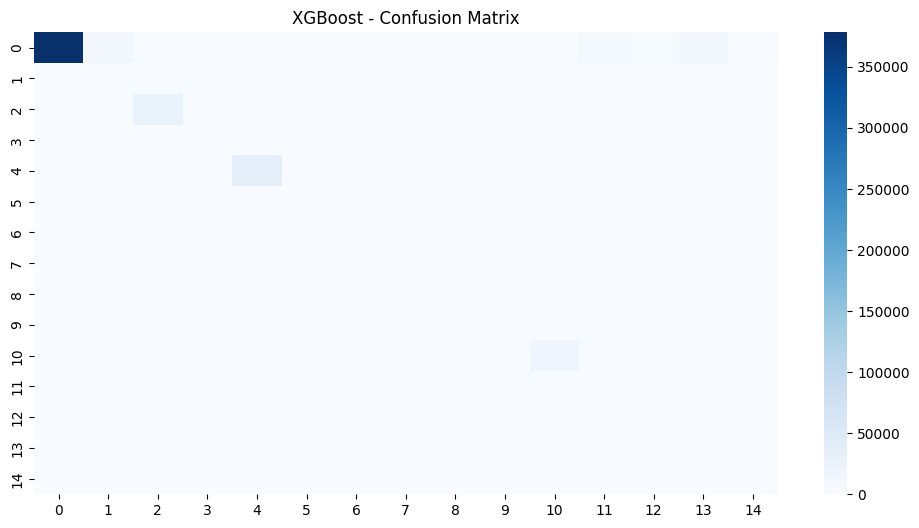

In [13]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Train XGBoost
xgb = XGBClassifier(
    n_estimators=200,       # number of boosting rounds
    learning_rate=0.1,      # step size shrinkage
    max_depth=8,            # depth of each tree
    subsample=0.8,          # row sampling
    colsample_bytree=0.8,   # feature sampling
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train_res, y_train_res)

# Predictions
y_pred_xgb = xgb.predict(X_test)

# Report
print("XGBoost Performance:")
print(classification_report(y_test, y_pred_xgb))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(12,6))
sns.heatmap(cm, annot=False, fmt="d", cmap="Blues")
plt.title("XGBoost - Confusion Matrix")
plt.show()


##### LIGHTGBM

In [15]:
!pip install lightgbm 

  Using cached lightgbm-4.6.0-py3-none-win_amd64.whl.metadata (17 kB)
Using cached lightgbm-4.6.0-py3-none-win_amd64.whl (1.5 MB)


SMOTE data not required

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.045868 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2173
[LightGBM] [Info] Number of data points in the train set: 2017889, number of used features: 12
[LightGBM] [Info] Start training from score -0.184934
[LightGBM] [Info] Start training from score -7.163840
[LightGBM] [Info] Start training from score -2.980794
[LightGBM] [Info] Start training from score -5.502143
[LightGBM] [Info] Start training from score -2.680534
[LightGBM] [Info] Start training from score -6.179018
[LightGBM] [Info] Start training from score -6.149333
[LightGBM] [Info] Start training from score -6.052505
[LightGBM] [Info] Start training from score -12.320338
[LightGBM] [Info] Start training from score -11.150267
[LightGBM] [Info] Start

c:\Users\vp532\OneDrive\Desktop\Mini_Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\vp532\OneDrive\Desktop\Mini_Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\vp532\OneDrive\Desktop\Mini_Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

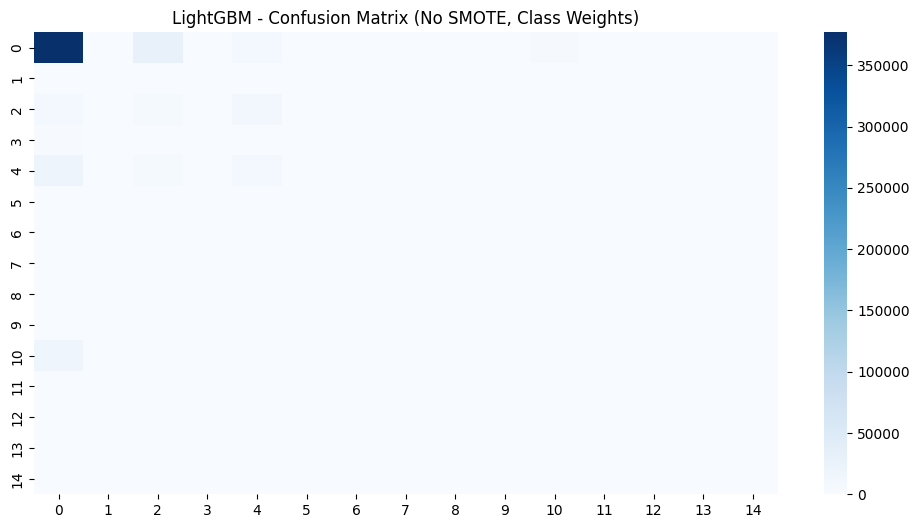

In [17]:
import lightgbm as lgb
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Train LightGBM without SMOTE, with class weighting
lgbm = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=128,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    is_unbalance=True,      # handles class imbalance
    random_state=42,
    n_jobs=-1
)

lgbm.fit(X_train, y_train)   #Note: use X_train, y_train (not SMOTE version)

# Predictions
y_pred_lgbm = lgbm.predict(X_test)

# Report
print("LightGBM Performance (with class weights, no SMOTE):")
print(classification_report(y_test, y_pred_lgbm))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lgbm)
plt.figure(figsize=(12,6))
sns.heatmap(cm, annot=False, fmt="d", cmap="Blues")
plt.title("LightGBM - Confusion Matrix (No SMOTE, Class Weights)")
plt.show()


#### LSTM

In [19]:
import numpy as np

# Convert train/test to numpy
X_train_lstm = np.array(X_train_res)
y_train_lstm = np.array(y_train_res)
X_test_lstm = np.array(X_test)
y_test_lstm = np.array(y_test)

# Reshape for LSTM: (samples, timesteps, features)
# Here timesteps = 1 (each row is one event)
X_train_lstm = X_train_lstm.reshape((X_train_lstm.shape[0], 1, X_train_lstm.shape[1]))
X_test_lstm = X_test_lstm.reshape((X_test_lstm.shape[0], 1, X_test_lstm.shape[1]))

print("Train shape for LSTM:", X_train_lstm.shape)
print("Test shape for LSTM:", X_test_lstm.shape)


Train shape for LSTM: (25157805, 1, 12)
Test shape for LSTM: (504473, 1, 12)


Shape of data: (samples, timesteps, features)

In [21]:
!pip install tensorflow

  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached gast-0.6.0-py3-none-any.whl.metadata (1.3 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached idna-3.10-py3-none-any.whl.metadata (10 kB)
  Using cached tensorboard_data_server-0.7.2-py3-none-any.whl.metadata (1.1 kB)
  Using cached werkzeug-3.1.3-py3-none-any.whl.metadata (3.7 kB)
  Using cached wheel-0.45.1-py3-none-any.whl.metadata (2.3 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ---------------------------------------- 0.0/331.9 MB ? eta -:--:--
   ---------------------------------------- 1.8/331.9 MB 10.1 MB/s eta 0:00:33
    --------------------------------------- 4.2/331.9 MB 10.5 MB/s eta 0:00:32
    --------------------------------------- 6.6/331.9 MB 10.9 MB/s eta 0:00:30
   - -----------

In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical

# One-hot encode labels for multiclass classification
num_classes = len(np.unique(y_train_lstm))
y_train_cat = to_categorical(y_train_lstm, num_classes=num_classes)
y_test_cat = to_categorical(y_test_lstm, num_classes=num_classes)

# Build LSTM model
model = Sequential()
model.add(LSTM(128, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2]), return_sequences=False))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(num_classes, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train model
history = model.fit(
    X_train_lstm, y_train_cat,
    epochs=10, batch_size=512,
    validation_split=0.2,
    verbose=1
)

# Evaluate
loss, acc = model.evaluate(X_test_lstm, y_test_cat, verbose=0)
print("LSTM Test Accuracy:", acc)


c:\Users\vp532\OneDrive\Desktop\Mini_Project\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
39310/39310 ━━━━━━━━━━━━━━━━━━━━ 216s 5ms/step - accuracy: 0.9172 - loss: 0.2724 - val_accuracy: 3.1024e-04 - val_loss: 11.4527
Epoch 2/10
39310/39310 ━━━━━━━━━━━━━━━━━━━━ 259s 7ms/step - accuracy: 0.9456 - loss: 0.1742 - val_accuracy: 3.1104e-04 - val_loss: 11.2008
Epoch 3/10
39310/39310 ━━━━━━━━━━━━━━━━━━━━ 267s 7ms/step - accuracy: 0.9496 - loss: 0.1610 - val_accuracy: 3.1422e-04 - val_loss: 11.3161
Epoch 4/10
39310/39310 ━━━━━━━━━━━━━━━━━━━━ 268s 7ms/step - accuracy: 0.9516 - loss: 0.1544 - val_accuracy: 3.1104e-04 - val_loss: 10.7652
Epoch 5/10
39310/39310 ━━━━━━━━━━━━━━━━━━━━ 233s 6ms/step - accuracy: 0.9530 - loss: 0.1500 - val_accuracy: 3.1422e-04 - val_loss: 11.3417
Epoch 6/10
39310/39310 ━━━━━━━━━━━━━━━━━━━━ 278s 7ms/step - accuracy: 0.9538 - loss: 0.1469 - val_accuracy: 3.1104e-04 - val_loss: 12.1077
Epoch 7/10
39310/39310 ━━━━━━━━━━━━━━━━━━━━ 283s 7ms/step - accuracy: 0.9543 - loss: 0.1448 - val_accuracy: 3.1442e-04 - val_loss: 11.4435
Epoch 8/10
39310/39310 ━━━━

LSTM → ~83% accuracy, but overfits on validation

15765/15765 ━━━━━━━━━━━━━━━━━━━━ 13s 830us/step
LSTM Performance:
              precision    recall  f1-score   support

           0       1.00      0.81      0.89    419297
           1       0.02      0.99      0.04       391
           2       0.89      0.99      0.94     25603
           3       0.60      0.99      0.75      2057
           4       0.92      0.88      0.90     34570
           5       0.72      0.97      0.82      1046
           6       0.49      0.96      0.65      1077
           7       0.02      1.00      0.05      1187
           8       0.11      1.00      0.20         2
           9       0.02      0.71      0.04         7
          10       0.72      0.99      0.84     18164
          11       0.34      0.93      0.50       644
          12       0.00      0.00      0.00       294
          13       0.00      0.00      0.00         4
          14       0.00      0.00      0.00       130

    accuracy                           0.83    504473
   macro avg  

c:\Users\vp532\OneDrive\Desktop\Mini_Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\vp532\OneDrive\Desktop\Mini_Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\vp532\OneDrive\Desktop\Mini_Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

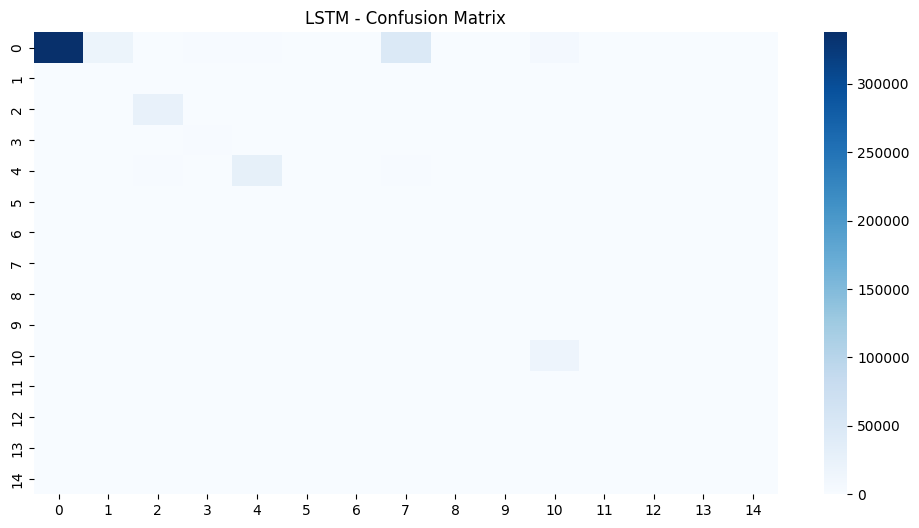

In [23]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Predict probabilities
y_pred_probs = model.predict(X_test_lstm)

# Convert probabilities → class labels
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = np.argmax(y_test_cat, axis=1)

# Classification report
print("LSTM Performance:")
print(classification_report(y_true_classes, y_pred_classes))

# Confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(12,6))
sns.heatmap(cm, annot=False, fmt="d", cmap="Blues")
plt.title("LSTM - Confusion Matrix")
plt.show()


Since Yeo–Johnson changes the feature distribution, we must re-do scaling and SMOTE afterwards. Otherwise, the synthetic distribution may not align properly.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer, MinMaxScaler
from imblearn.over_sampling import SMOTE

def preprocess_for_linear_models(df, target_col="label_multi_enc", test_size=0.2, random_state=42):
    """
    Preprocess dataset for Logistic Regression / KNN / SVM:
    - Train-test split
    - Yeo-Johnson transformation
    - Min-Max scaling
    - SMOTE on training set
    """
    X = df.drop(columns=[target_col])
    y = df[target_col]
    
    # Train-test split (stratified)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=random_state
    )
    
    # Yeo-Johnson transformation
    pt = PowerTransformer(method='yeo-johnson')
    X_train_trans = pt.fit_transform(X_train)
    X_test_trans = pt.transform(X_test)
    
    # Min-Max scaling
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train_trans)
    X_test_scaled = scaler.transform(X_test_trans)
    
    # Apply SMOTE only on training
    sm = SMOTE(random_state=random_state, k_neighbors=5)
    X_train_res, y_train_res = sm.fit_resample(X_train_scaled, y_train)
    
    return X_train_res, X_test_scaled, y_train_res, y_test


#### LOGISTIC REGRESSION

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Preprocess once
X_train_res, X_test_scaled, y_train_res, y_test = preprocess_for_linear_models(df)

# Train Logistic Regression
lr = LogisticRegression(max_iter=500, n_jobs=-1)
lr.fit(X_train_res, y_train_res)

# Predict
y_pred_lr = lr.predict(X_test_scaled)

# Report
print("Logistic Regression Performance:")
print(classification_report(y_test, y_pred_lr))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(12,6))
sns.heatmap(cm, annot=False, fmt="d", cmap="Blues")
plt.title("Logistic Regression - Confusion Matrix")
plt.show()
